### Import

In [13]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score

import cv2

import src.setup as setup
from src.setup import cfg, load_train_df, train_dir

from sklearn.model_selection import StratifiedShuffleSplit

In [14]:
cur = Path.cwd().resolve()
if (cur / "src").exists():
    model_dir = cur
elif (cur.parent / "src").exists():
    model_dir = cur.parent
else:
    raise FileNotFoundError("cannot find Model/src. open notebook under CVProject/Model or CVProject/Model/notebooks")

if str(model_dir) not in sys.path:
    sys.path.insert(0, str(model_dir))

print("model_dir:", model_dir)

model_dir: /root/CVProject/Model


In [15]:
train_df = load_train_df()
num_classes = train_df["target"].nunique()

print("train_df:", train_df.shape)
print("num_classes:", num_classes)

# OOF 경로
oof_dir = Path(cfg["paths"]["oof_dir"])
oof_path = oof_dir / "oof_probs.npy"

print("oof_path exists:", oof_path.exists(), "|", oof_path)

train_df: (1570, 2)
num_classes: 17
oof_path exists: True | /root/CVProject/Model/artifacts/oof/oof_probs.npy


In [16]:
oof_probs = np.load(oof_path).astype(np.float32)  # (N, C)
assert oof_probs.shape[0] == len(train_df)
assert oof_probs.shape[1] == num_classes

oof_true = train_df["target"].values.astype(np.int64)
oof_pred = oof_probs.argmax(axis=1)
oof_conf = oof_probs.max(axis=1)

# dev/lb 재구성 (cfg 기준)
if cfg.get("use_lb_holdout", False):
    sss = StratifiedShuffleSplit(
        n_splits=1,
        test_size=cfg.get("lb_holdout_ratio", 0.2),
        random_state=cfg.get("lb_holdout_seed", cfg["seed"])
    )
    dev_idx, lb_idx = next(sss.split(train_df, train_df["target"]))
    dev_idx = np.array(dev_idx)
    lb_idx  = np.array(lb_idx)
    print("dev:", len(dev_idx), "| lb:", len(lb_idx))
else:
    dev_idx = np.arange(len(train_df))
    lb_idx = None
    print("dev uses full train")

# dev에서 OOF 점수 확인
dev_f1 = f1_score(oof_true[dev_idx], oof_pred[dev_idx], average="macro")
print("OOF macro_f1 (dev):", dev_f1)

dev: 1256 | lb: 314
OOF macro_f1 (dev): 0.9373107474180271


In [17]:
cm = confusion_matrix(oof_true[dev_idx], oof_pred[dev_idx], labels=list(range(num_classes)))

# 혼동쌍(정답 i -> 예측 j) 상위 추출 (i!=j)
pairs = []
for i in range(num_classes):
    row_sum = cm[i].sum()
    if row_sum == 0:
        continue
    for j in range(num_classes):
        if i == j:
            continue
        cnt = cm[i, j]
        if cnt > 0:
            pairs.append((cnt, i, j, cnt / row_sum))

pairs_sorted = sorted(pairs, key=lambda x: x[0], reverse=True)

print("Top confusion pairs (count, gt, pred, ratio_in_gt):")
for k in range(min(20, len(pairs_sorted))):
    cnt, gt, pr, r = pairs_sorted[k]
    print(f"{k:02d} | cnt={cnt:4d} | gt={gt:2d} -> pred={pr:2d} | ratio={r:.3f}")


Top confusion pairs (count, gt, pred, ratio_in_gt):
00 | cnt=  21 | gt= 7 -> pred= 3 | ratio=0.263
01 | cnt=  13 | gt= 3 -> pred= 7 | ratio=0.163
02 | cnt=   6 | gt= 4 -> pred= 7 | ratio=0.075
03 | cnt=   5 | gt=14 -> pred= 4 | ratio=0.125
04 | cnt=   4 | gt= 7 -> pred= 4 | ratio=0.050
05 | cnt=   4 | gt=14 -> pred= 3 | ratio=0.100
06 | cnt=   3 | gt= 4 -> pred=14 | ratio=0.037
07 | cnt=   3 | gt=11 -> pred=10 | ratio=0.037
08 | cnt=   2 | gt=13 -> pred= 6 | ratio=0.034
09 | cnt=   1 | gt= 3 -> pred= 4 | ratio=0.013
10 | cnt=   1 | gt= 3 -> pred=13 | ratio=0.013
11 | cnt=   1 | gt= 7 -> pred=13 | ratio=0.013
12 | cnt=   1 | gt= 7 -> pred=14 | ratio=0.013
13 | cnt=   1 | gt=10 -> pred= 3 | ratio=0.013
14 | cnt=   1 | gt=10 -> pred=11 | ratio=0.013
15 | cnt=   1 | gt=11 -> pred= 1 | ratio=0.013
16 | cnt=   1 | gt=11 -> pred=12 | ratio=0.013
17 | cnt=   1 | gt=12 -> pred= 6 | ratio=0.013
18 | cnt=   1 | gt=12 -> pred=13 | ratio=0.013
19 | cnt=   1 | gt=13 -> pred= 0 | ratio=0.017


In [18]:
focus = [3, 7, 14]  # 필요하면 cfg로 빼도 됨

for gt in focus:
    row = cm[gt]
    total = row.sum()
    if total == 0:
        continue
    # top-5 preds for this gt
    top = np.argsort(-row)[:5]
    print(f"\n[GT={gt}] total={total}")
    for pr in top:
        print(f"  pred={pr:2d} | cnt={row[pr]:4d} | ratio={row[pr]/total:.3f}")



[GT=3] total=80
  pred= 3 | cnt=  65 | ratio=0.812
  pred= 7 | cnt=  13 | ratio=0.163
  pred= 4 | cnt=   1 | ratio=0.013
  pred=13 | cnt=   1 | ratio=0.013
  pred= 2 | cnt=   0 | ratio=0.000

[GT=7] total=80
  pred= 7 | cnt=  53 | ratio=0.662
  pred= 3 | cnt=  21 | ratio=0.263
  pred= 4 | cnt=   4 | ratio=0.050
  pred=14 | cnt=   1 | ratio=0.013
  pred=13 | cnt=   1 | ratio=0.013

[GT=14] total=40
  pred=14 | cnt=  30 | ratio=0.750
  pred= 4 | cnt=   5 | ratio=0.125
  pred= 3 | cnt=   4 | ratio=0.100
  pred= 7 | cnt=   1 | ratio=0.025
  pred= 2 | cnt=   0 | ratio=0.000


In [19]:
# ---- suspect criteria ----
CONF_TH = 0.90
ONLY_DEV = True   # OOF가 dev에서만 의미 있으니 기본 True
FOCUS_CLASSES = set([3, 7, 14])  # 혼동 집중 클래스들

idx_pool = dev_idx if ONLY_DEV else np.arange(len(train_df))

wrong = (oof_pred != oof_true)
highconf = (oof_conf >= CONF_TH)

# focus 조건: gt 또는 pred가 focus에 포함되는 샘플만
focus_mask = np.array([(int(oof_true[i]) in FOCUS_CLASSES) or (int(oof_pred[i]) in FOCUS_CLASSES) for i in idx_pool])

sus_mask_pool = wrong[idx_pool] & highconf[idx_pool] & focus_mask
sus_idx = idx_pool[sus_mask_pool]

print("suspects:", len(sus_idx), f"({len(sus_idx)/len(idx_pool):.3%} of pool)")

# 결과 테이블 만들기
sus_df = train_df.loc[sus_idx, ["ID", "target"]].copy()
sus_df["oof_pred"] = oof_pred[sus_idx]
sus_df["oof_conf"] = oof_conf[sus_idx]

# 추가로 예측 확률 top2 정보
top2 = np.argsort(-oof_probs[sus_idx], axis=1)[:, :2]
sus_df["top1"] = top2[:, 0]
sus_df["top2"] = top2[:, 1]
sus_df["p_top1"] = oof_probs[sus_idx, sus_df["top1"].values]
sus_df["p_top2"] = oof_probs[sus_idx, sus_df["top2"].values]

sus_df = sus_df.sort_values("oof_conf", ascending=False).reset_index(drop=False)  # drop=False로 원본 idx 보관
sus_df.rename(columns={"index": "orig_idx"}, inplace=True)

sus_df.head(10)


suspects: 33 (2.627% of pool)


,orig_idx,ID,target,oof_pred,oof_conf,top1,top2,p_top1,p_top2
0,493,4f1a0debe89c7641.jpg,7,3,0.999569,3,7,0.999569,0.000314
1,1535,f9b5addf7a5b4407.jpg,4,7,0.999400,7,4,0.999400,0.000448
2,132,1495a1e3d1599fe1.jpg,7,3,0.997817,3,7,0.997817,0.001740
3,165,1ab6b4d6b1ebe5dd.jpg,7,3,0.997419,3,7,0.997419,0.002561
4,720,706f88bd829080ed.jpg,14,7,0.997243,7,3,0.997243,0.002560
5,1206,c039533391ddbe53.jpg,7,3,0.996969,3,7,0.996969,0.002057
6,1034,a602d3c2110909cc.jpg,3,7,0.996194,7,3,0.996194,0.003692
7,220,24ccb7ee55e01794.jpg,10,3,0.995342,3,2,0.995342,0.001956
8,605,5f047c4d27c6d01e.jpg,7,3,0.994693,3,14,0.994693,0.002202
9,1095,aec62dced7af97cd.jpg,3,4,0.994534,4,7,0.994534,0.004696


In [20]:
out_path = oof_dir / "suspects_focus_highconf.csv"
sus_df.to_csv(out_path, index=False)
print("saved:", out_path)


saved: /root/CVProject/Model/artifacts/oof/suspects_focus_highconf.csv


In [21]:
def show_grid(indices, n=12, cols=4, title=None):
    n = min(n, len(indices))
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(4*cols, 4*rows))
    if title is not None:
        plt.suptitle(title, fontsize=14)

    for i in range(n):
        idx = int(indices[i])
        img_path = Path(train_dir) / train_df.loc[idx, "ID"]
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        gt = int(oof_true[idx])
        pr = int(oof_pred[idx])
        conf = float(oof_conf[idx])

        plt.subplot(rows, cols, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"idx={idx}\nGT={gt} / PR={pr} ({conf:.2f})", fontsize=10)

    plt.tight_layout()
    plt.show()


3 -> 7: 13
7 -> 3: 21
3 -> 7 (conf>=0.9): 9
7 -> 3 (conf>=0.9): 12


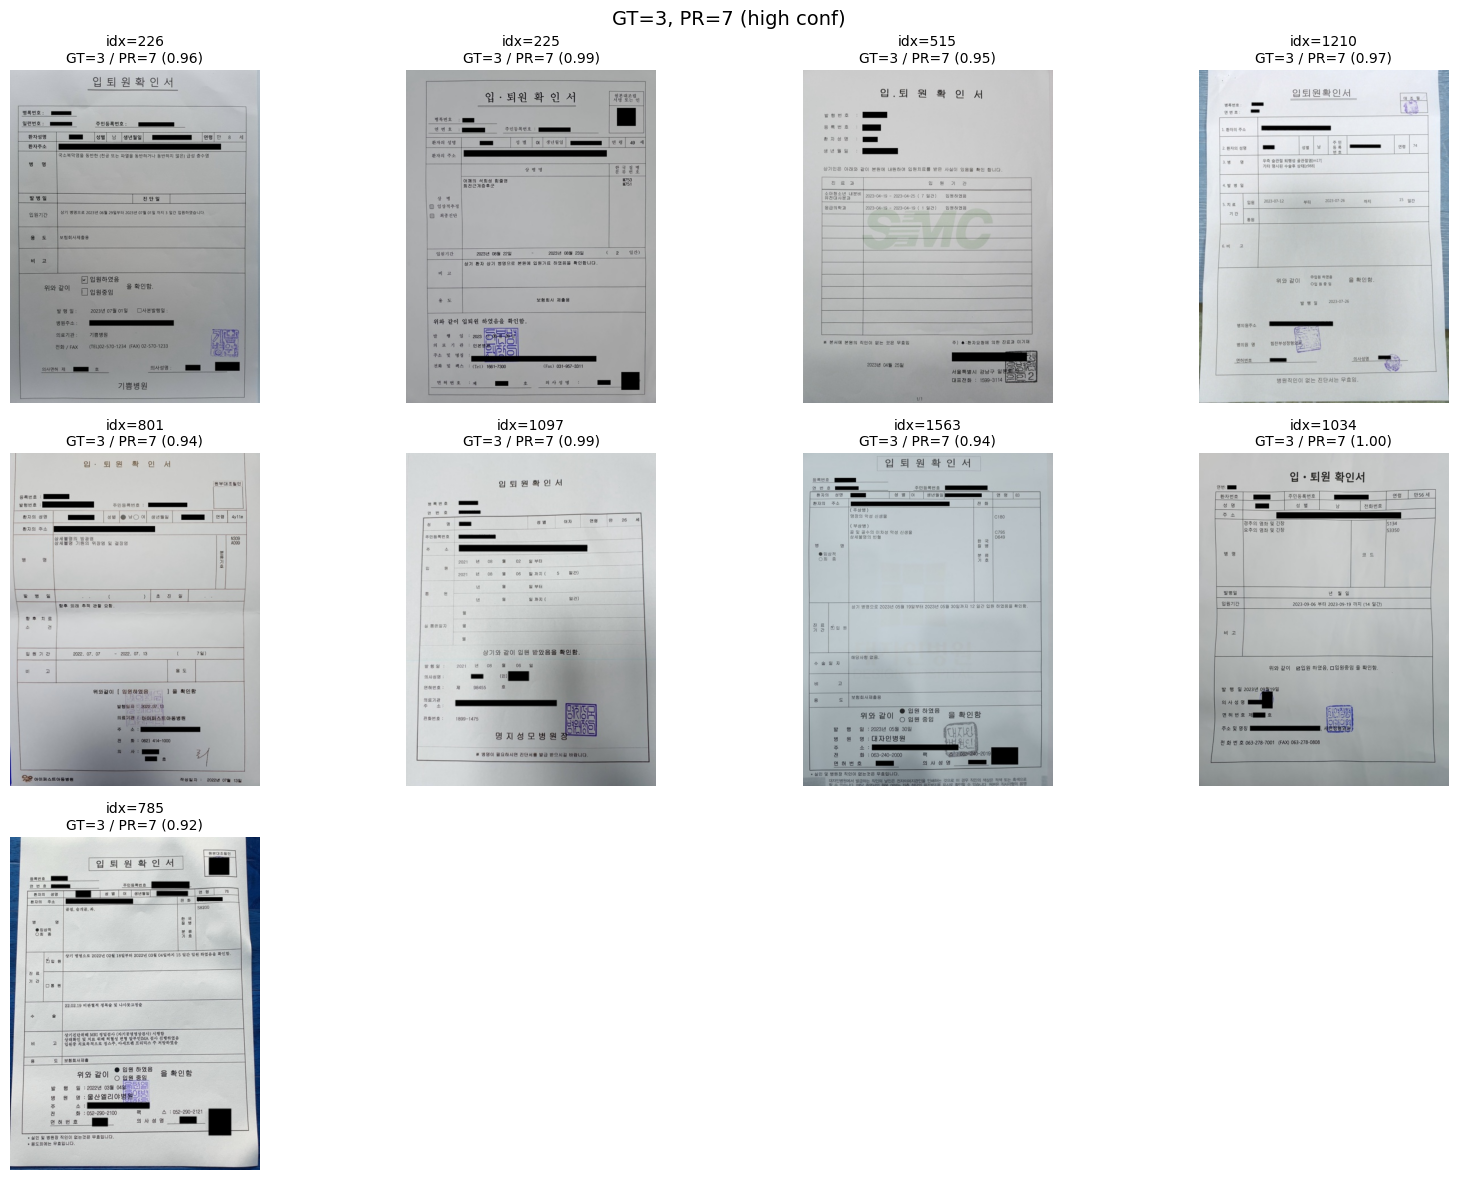

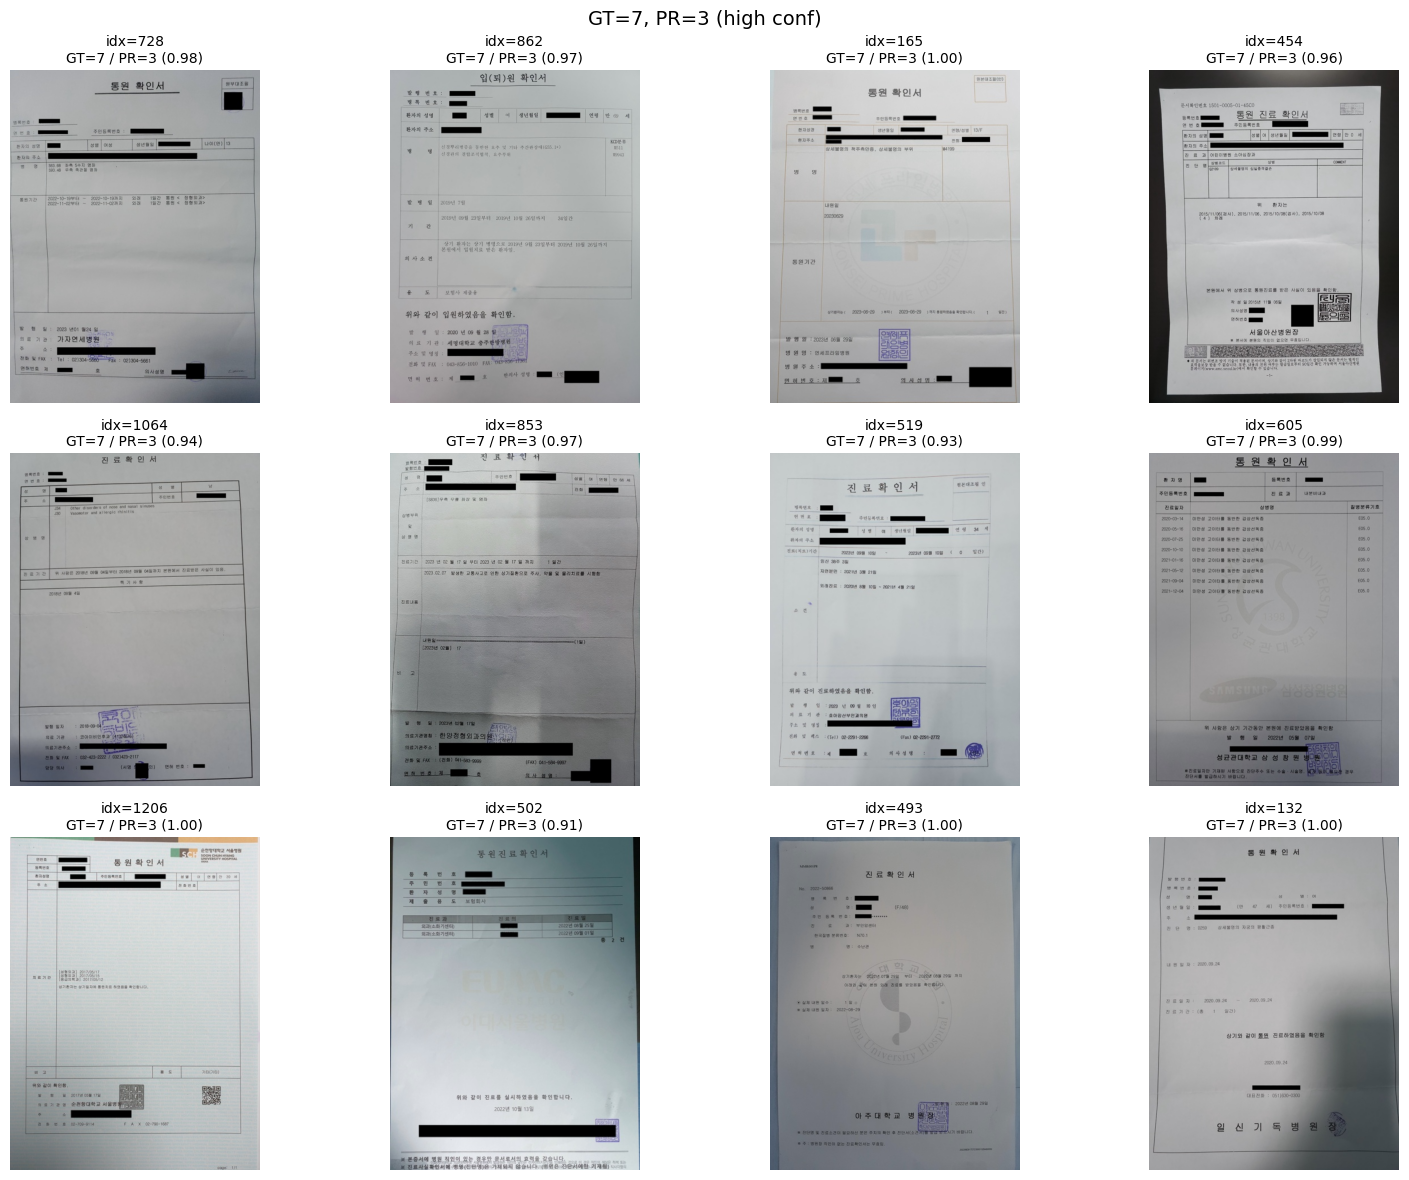

In [22]:
def filter_pair(gt, pr, idx_pool):
    m = (oof_true[idx_pool] == gt) & (oof_pred[idx_pool] == pr)
    return idx_pool[m]

idx_pool = dev_idx

pair_3_7 = filter_pair(3, 7, idx_pool)
pair_7_3 = filter_pair(7, 3, idx_pool)

print("3 -> 7:", len(pair_3_7))
print("7 -> 3:", len(pair_7_3))

# high conf only
pair_3_7_h = pair_3_7[oof_conf[pair_3_7] >= 0.9]
pair_7_3_h = pair_7_3[oof_conf[pair_7_3] >= 0.9]

print("3 -> 7 (conf>=0.9):", len(pair_3_7_h))
print("7 -> 3 (conf>=0.9):", len(pair_7_3_h))

show_grid(pair_3_7_h, n=12, cols=4, title="GT=3, PR=7 (high conf)")
show_grid(pair_7_3_h, n=12, cols=4, title="GT=7, PR=3 (high conf)")


In [23]:
alpha = 0.05  # cfg에서 가져와도 됨

# hard one-hot for suspects
C = num_classes
hard = np.zeros((len(sus_idx), C), dtype=np.float32)
hard[np.arange(len(sus_idx)), oof_true[sus_idx]] = 1.0

soft = (1.0 - alpha) * hard + alpha * oof_probs[sus_idx]

save_idx = oof_dir / "soft_targets_idx.npy"
save_soft = oof_dir / "soft_targets_prob.npy"

np.save(save_idx, sus_idx)
np.save(save_soft, soft)

print("saved:", save_idx)
print("saved:", save_soft)
print("soft shape:", soft.shape)


saved: /root/CVProject/Model/artifacts/oof/soft_targets_idx.npy
saved: /root/CVProject/Model/artifacts/oof/soft_targets_prob.npy
soft shape: (33, 17)
